In [3]:
import yfinance as yf
from sklearn.model_selection import train_test_split
from skfolio.optimization import MeanRisk, ObjectiveFunction, MaximumDiversification, HierarchicalRiskParity, EqualWeighted, SchurComplementary, HierarchicalEqualRiskContribution
from skfolio.distance import DistanceCorrelation, MutualInformation
from skfolio.preprocessing import prices_to_returns
from skfolio import PerfMeasure, RiskMeasure, RatioMeasure, Population

In [4]:
# (fund name as in the source table, ISIN)
FUNDS = [
    #("Carmignac Sécurité A EUR Acc", "FR0010149120"),
    ("CD Défensif", "FR0010219501"),
    #("Carmignac Crédit 2027 A EUR Acc", "FR00140081Y1"),
    ("MSIF Global Convertible Bonds EUR", "LU0149084633"),
    ("M&G Emerging Bond Euro", "LU1670631289"),
    #("DNCA Invest Flex Inflation B EUR", "LU1694790202"),
    #("Lazard Credit Opportunities", "FR0010230490"),
    ("BGF European High Yield Bond A2", "LU1191877379"),
    #("CD Alpha Bonds C", "FR0010249664"),
    #("Butler Credit Opportunities", "IE00BMVX2J49"),
    #("Lazard Patrimoine Opportunitie SRI", "FR0007028543"),
    #("Lazard Patrimoine Croissance FR", "FR0000292302"),
    #("CM-AM Flexible Euro RC", "FR0013384336"),
    #("Madeleine Opportunities", "LU0961755823"),
    #("Renaissance Europe C", "FR0000295230"),
    ("GS Europe CORE Equity Base Acc EUR", "LU0234682044"), # this should be LU0234681749 but yfinance fails to source it. LU0234682044 has different fee structure but similar performance. We use it as a proxy
    #("CM-AM Convictions Euro RC", "FR0013384963"),
    #("JPMF Euroland Equity A Acc EUR", "LU0210529490"),
    #("UBS European Equity Value Opp P EUR", "LU0153925689"),
    ("Sycomore Sélection Responsable R", "FR0011169341"),
    #("Goldman Sachs Eurozone Equity Income RC C EUR", "LU0127786431"),
    #("CD Euro Capital", "FR0010250084"),
    ("Mirova Euro Sustainable Equity", "LU0914731947"),
    #("CD France Expertise", "FR0010249672"),
    #("Oudart Opportunités France", "FR0010166140"),
    #("Madeleine Mid Caps Euro", "LU1044932975"),
    #("Lazard Equity SRI RC EUR", "LU0013204187"),
    ("Indépendance Europe Small", "LU1832174962"),
    #("Franklin US Opportunities A Acc EUR", "LU0260869739"),
    #("Nordea 1 North American Stars Equity", "LU0772958012"),
    #("T. Rowe Price US Smlr Cm Eq A EUR", "LU0918140210"),
    #("Robeco QI EM Active Equities", "LU0329355670"),
    #("M&G Lux Global Emerg Mkt Fd A EUR Acc", "LU1670618690"),
    #("Nordea 1 - Emerging Stars Equity BP EUR", "LU0602539867"),
    #("Ofi Invest Actions Japon", "FR0013392065"),
    ("RobecoSAM Smart Energy B EUR Acc", "LU2145461757"),
    #("Fidelity Global Technology A-Acc-EUR", "LU1213836080"),
    ("BlackRock World Gold Fund", "RING"), # RING is an ETF, we use it as a proxy to LU0171305526 
    ("RobecoSAM Sustainable Water B EUR", "0P0001KWKR.F"), # should be LU2146190835 but yfinance maps it to `Robeco Capital Growth Funds` ...
    #("M&G Episode Macro", "LU1670714226"),
    #("BDL Rempart C", "FR0010174144"),
    #("BGF World Healthscience A2", "LU0171307068"),
    #("Eleva UCITS Eleva Abs Ret Eurp Eq A acc", "LU1920211973"),
    ("Schroder ISF Glb Clmt Chg Eq A Acc EUR", "0P00008YCS.F"), # should be LU0302446645. Again, slightly different exchange/fee structure but we can use as proxy
    #("SLF LUX Eq Env & Biodiv Imp EUR R Acc", "LU2349917364"),
    #("Pictet Robotics P EUR Acc", "LU1279334210"),  #FIXME
    ("BDL transition", "LU1988108350"),  # ISIN partially cut off in source image - verify
]


def resolve_isin(isin: str):
    """Query Yahoo's search backend for a ticker matching this ISIN."""
    try:
        results = yf.Search(isin, max_results=5).quotes
    except Exception as e:
        return None, f"ERROR: {e}"

    if not results:
        return None, "NOT FOUND"

    # Return the top match; also surface alternates if Yahoo found several
    top = results[0]
    symbol = top.get("symbol")
    longname = top.get("longname") or top.get("shortname") or ""
    note = "" if len(results) == 1 else f"({len(results)} matches, double-check share class)"
    return symbol, f"{longname} {note}".strip()

assets = {resolve_isin(pair[1])[0] : pair[0] for pair in FUNDS if resolve_isin(pair[1])[0] is not None}
assets


{'0P00000Q9A.F': 'CD Défensif',
 '0P00000SHW': 'MSIF Global Convertible Bonds EUR',
 '0P0001DFNP.F': 'M&G Emerging Bond Euro',
 '0P00016H0K.F': 'BGF European High Yield Bond A2',
 '0P00008WGI.F': 'GS Europe CORE Equity Base Acc EUR',
 '0P0000V0BE.F': 'Sycomore Sélection Responsable R',
 '0P000100RL.F': 'Mirova Euro Sustainable Equity',
 '0P0001DKPM.F': 'Indépendance Europe Small',
 'RING': 'BlackRock World Gold Fund',
 '0P0001KWKR.F': 'RobecoSAM Sustainable Water B EUR',
 '0P00008YCS.F': 'Schroder ISF Glb Clmt Chg Eq A Acc EUR',
 '0P0001IDJ3.F': 'BDL transition'}

In [78]:
df = yf.download(list(assets), period='10y', interval='1d', multi_level_index=False).Close.rename(assets, axis=1)
returns = prices_to_returns(df, nan_threshold=0.6, drop_inceptions_nan=True, fill_nan=True).bfill()
assert not returns.isna().sum().sum() and len(df) > 0
print(returns.shape, returns.index.min(), returns.index.max(), '\n\n')
for col in df.columns:
    print(col, df[col].dropna().index.min())

[*********************100%***********************]  12 of 12 completed

(1069, 12) 2022-03-09 00:00:00 2026-06-22 00:00:00 


CD Défensif 2018-01-02 00:00:00
MSIF Global Convertible Bonds EUR 2022-03-07 00:00:00
GS Europe CORE Equity Base Acc EUR 2022-03-07 00:00:00
Schroder ISF Glb Clmt Chg Eq A Acc EUR 2022-03-07 00:00:00
Sycomore Sélection Responsable R 2018-01-02 00:00:00
Mirova Euro Sustainable Equity 2022-03-07 00:00:00
BGF European High Yield Bond A2 2022-03-07 00:00:00
M&G Emerging Bond Euro 2022-03-08 00:00:00
Indépendance Europe Small 2022-03-07 00:00:00
BDL transition 2022-03-07 00:00:00
RobecoSAM Sustainable Water B EUR 2022-03-07 00:00:00
BlackRock World Gold Fund 2016-06-24 00:00:00


<Axes: xlabel='Date'>

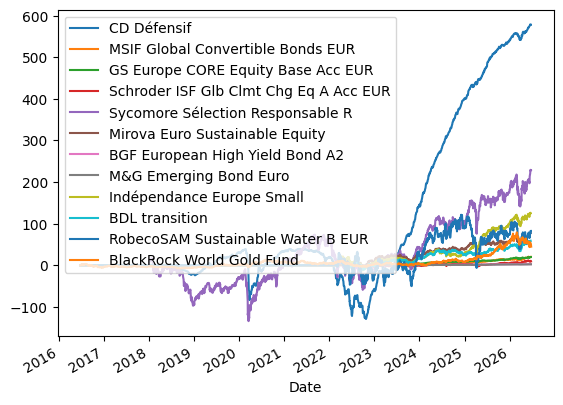

In [79]:
import polars as pl
import polars.selectors as cs
pl.from_pandas(df, include_index=True).with_columns(cs.numeric().backward_fill() - cs.numeric().backward_fill().first()).to_pandas().set_index('Date').plot()

In [ ]:
#X = prices_to_returns(returns)
X_train, X_test = train_test_split(returns, test_size=0.4, shuffle=False)
print(X_train.index.max(), X_test.index.max())
kwargs = dict(
    solver="SCIP", 
    min_weights=0.05,
    max_weights={'CD Défensif': .1},
    #risk_free_rate=0.03,  # FIXME
    #management_fees=0.01,  # FIXME
)

pop = Population([])
models = dict()

for model in (
    MeanRisk(risk_measure=RiskMeasure.SEMI_DEVIATION, objective_function=ObjectiveFunction.MAXIMIZE_RATIO, **kwargs), 
    MaximumDiversification(**kwargs),
    HierarchicalRiskParity(risk_measure=RiskMeasure.SEMI_DEVIATION, distance_estimator=MutualInformation()),
    EqualWeighted(),  # THIS IS OUR BASELINE
    SchurComplementary(distance_estimator=MutualInformation()),
    HierarchicalEqualRiskContribution(distance_estimator=MutualInformation()),
    ):
    model.fit(X_train)
    pop.append(model.predict(X_test))
    models[type(model).__name__] = model


pop.plot_cumulative_returns()

In [20]:
pop.rolling_measure(RiskMeasure.MAX_DRAWDOWN, window=30).max()

MeanRisk                             0.076261
MaximumDiversification               0.073558
HierarchicalRiskParity               0.044292
EqualWeighted                        0.094721
SchurComplementary                   0.004599
HierarchicalEqualRiskContribution    0.006628
dtype: float64

In [21]:
pop.plot_rolling_measure(RiskMeasure.MAX_DRAWDOWN, window=30)

In [22]:
pop.plot_rolling_measure(RiskMeasure.SEMI_VARIANCE, window=30)

In [23]:
pop.summary().loc[[
    'Annualized Mean', 
    'Annualized Semi-Variance',
    'MAX Drawdown', 
    'Value at Risk at 95%',
    'Annualized Sortino Ratio', 
    'Calmar Ratio', 
    'Annualized Sharpe Ratio'
]]

,MeanRisk,MaximumDiversification,HierarchicalRiskParity,EqualWeighted,SchurComplementary,HierarchicalEqualRiskContribution
Annualized Mean,12.42%,12.47%,7.08%,15.23%,2.97%,3.30%
Annualized Semi-Variance,0.29%,0.28%,0.083%,0.51%,0.00098%,0.0019%
MAX Drawdown,7.64%,7.36%,4.49%,9.47%,0.46%,0.66%
Value at Risk at 95%,0.67%,0.66%,0.36%,0.86%,0.031%,0.048%
Annualized Sortino Ratio,2.31,2.36,2.46,2.14,9.49,7.60
Calmar Ratio,0.0065,0.0067,0.0063,0.0064,0.026,0.020
Annualized Sharpe Ratio,1.69,1.73,1.80,1.56,6.93,5.74


In [24]:
import pandas as pd
pd.DataFrame({name: dict(zip(model.feature_names_in_, model.weights_)) for name, model in models.items()})

,MeanRisk,MaximumDiversification,HierarchicalRiskParity,EqualWeighted,SchurComplementary,HierarchicalEqualRiskContribution
CD Défensif,0.100000,0.050000,0.535199,0.083333,9.672932e-01,0.935582
MSIF Global Convertible Bonds EUR,0.050000,0.050000,0.055560,0.083333,1.428749e-03,0.011521
GS Europe CORE Equity Base Acc EUR,0.129712,0.050000,0.046259,0.083333,1.192163e-03,0.003419
Schroder ISF Glb Clmt Chg Eq A Acc EUR,0.050000,0.050000,0.043151,0.083333,7.805972e-04,0.002386
Sycomore Sélection Responsable R,0.050000,0.050000,0.018404,0.083333,1.020097e-06,0.001372
Mirova Euro Sustainable Equity,0.050000,0.050000,0.018224,0.083333,9.036882e-07,0.001373
BGF European High Yield Bond A2,0.320288,0.347476,0.092301,0.083333,2.417225e-02,0.023689
M&G Emerging Bond Euro,0.050000,0.130065,0.058813,0.083333,2.268848e-03,0.012310
Indépendance Europe Small,0.050000,0.050000,0.031723,0.083333,7.656215e-04,0.004024
BDL transition,0.050000,0.050000,0.038769,0.083333,2.736237e-06,0.001603
